# Assignment 02 — House Price Prediction

**Problem:** House-price regression  
**Dataset:** `house_buying_dec29th_2025.csv`  
**Target:** `price_million_vnd` (million VND)

This notebook follows the required Appendix B notebook structure and Appendix A repository structure from Assignment 02: data definition → inspection → cleaning → representation → EDA → split → preprocessing → five models → evaluation → error analysis → persistence → inference.

**Dataset-source note:** the supplied PDF requires a Kaggle dataset name and URL, but the uploaded CSV/PDF does not identify that URL. Therefore no Kaggle URL is invented; insert the verified URL if you have it.

## 1. Problem Definition

The objective is to predict the price of a house from its characteristics.

- **X = house characteristics**
- **y = house price**
- **Task = regression**
- **One row = one house listing**
- **Target unit = million VND**

In [1]:
from pathlib import Path
import json
import sys
import platform
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib


# ============================================================
# 1. BASIC CONFIGURATION
# ============================================================

warnings.filterwarnings("ignore")

RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)


# ============================================================
# 2. PROJECT STRUCTURE
# ============================================================

# Notebook nằm tại:
#
# Assignment_02/
# └── house_price/
#     ├── data/
#     │   └── house_buying_dec29th_2025.csv
#     ├── notebook/
#     │   └── house_price_prediction_assignment02.ipynb
#     └── model/
#
# Vì notebook nằm trong thư mục "notebook",
# PROJECT_ROOT chính là thư mục cha của "notebook".

CURRENT_DIR = Path.cwd().resolve()

print("Current working directory:")
print(CURRENT_DIR)


# Nếu đang chạy notebook từ thư mục notebook/
if CURRENT_DIR.name.lower() == "notebook":
    PROJECT_ROOT = CURRENT_DIR.parent

# Nếu Jupyter đang chạy từ thư mục project house_price/
elif (CURRENT_DIR / "data").exists():
    PROJECT_ROOT = CURRENT_DIR

# Trường hợp Jupyter đang chạy từ Assignment_02/
elif (CURRENT_DIR / "house_price" / "data").exists():
    PROJECT_ROOT = CURRENT_DIR / "house_price"

else:
    raise FileNotFoundError(
        "Không tìm thấy thư mục project house_price.\n"
        "Hãy đảm bảo cấu trúc thư mục là:\n\n"
        "Assignment_02/\n"
        "└── house_price/\n"
        "    ├── data/\n"
        "    │   └── house_buying_dec29th_2025.csv\n"
        "    └── notebook/\n"
        "        └── house_price_prediction_assignment02.ipynb"
    )


# ============================================================
# 3. DATA / MODEL PATH
# ============================================================

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "house_buying_dec29th_2025.csv"
)

MODEL_DIR = PROJECT_ROOT / "model"

# Tự động tạo thư mục model nếu chưa tồn tại
MODEL_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# 4. CHECK PATH
# ============================================================

print("\n========== PROJECT INFORMATION ==========")

print("Project root:")
print(PROJECT_ROOT)

print("\nDataset path:")
print(DATA_PATH)

print("\nDataset exists:")
print(DATA_PATH.exists())

print("\nModel directory:")
print(MODEL_DIR)

print("\nModel directory exists:")
print(MODEL_DIR.exists())


# Nếu dataset không tồn tại thì báo lỗi rõ ràng
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"\nKhông tìm thấy dataset:\n{DATA_PATH}\n\n"
        "Hãy kiểm tra file "
        "'house_buying_dec29th_2025.csv' "
        "có nằm trong thư mục data hay không."
    )


# ============================================================
# 5. ENVIRONMENT INFORMATION
# ============================================================

print("\n========== ENVIRONMENT ==========")

print("Python:", sys.version.split()[0])
print("OS:", platform.platform())
print("Random seed:", RANDOM_SEED)

print("\nReady to load dataset.")

Current working directory:
D:\Dai hoc\Phat trien cac he thong thong minh\Assignment_02\house_price\notebook

========== PROJECT INFORMATION ==========
Project root:
D:\Dai hoc\Phat trien cac he thong thong minh\Assignment_02\house_price

Dataset path:
D:\Dai hoc\Phat trien cac he thong thong minh\Assignment_02\house_price\data\house_buying_dec29th_2025.csv

Dataset exists:
True

Model directory:
D:\Dai hoc\Phat trien cac he thong thong minh\Assignment_02\house_price\model

Model directory exists:
True

========== ENVIRONMENT ==========
Python: 3.14.6
OS: Windows-11-10.0.26200-SP0
Random seed: 42

Ready to load dataset.


## 2. Dataset Source and Loading

In [2]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
display(df.head())

Shape: (66912, 11)


,id,detail_url,title,location,timeline_hours,area_m2,bedrooms,bathrooms,floors,frontage,price_million_vnd
0,196958,https://batdongsan.vn/ban-nha-nguyen-son-long-...,Bán nhà Nguyễn Sơn Long Biên- Dân trí Tuyệt vờ...,"Long Biên, Hà Nội",2,50.0,4.0,4.0,6.0,False,12500.0
1,196967,https://batdongsan.vn/ban-nha-hem-xe-hoi-4m-2-...,"BÁN NHÀ HẺM XE HƠI 4M, 2 MẶT TIỀN - 2 TẦNG , N...","Bình Chánh, Hồ Chí Minh",2,98.0,4.0,4.0,3.0,True,5500.0
2,196983,https://batdongsan.vn/o-to-ngu-nha-62m2-5-tang...,Ô TÔ NGỦ NHÀ – 62M² – 5 Tầng/4PN – Gần kdc CIT...,"Gò Vấp, Hồ Chí Minh",2,62.0,4.0,5.0,6.0,False,8740.0
3,196962,https://batdongsan.vn/ban-nha-phuc-loi-ngo-non...,Bán nhà Phúc Lợi - ngõ nông - ô tô vào nhà - t...,"Long Biên, Hà Nội",2,39.0,3.0,4.0,6.0,False,6500.0
4,196972,https://batdongsan.vn/tran-duy-hung-6-tang-tha...,TRẦN DUY HƯNG - 6 TẦNG THANG MÁY - NGÕ THÔNG D...,"Cầu Giấy, Hà Nội",2,45.0,3.0,3.0,7.0,True,16980.0


## 3. Dataset Inspection

In [3]:
print("df.shape")
print(df.shape)

print("\ndf.head()")
display(df.head())

print("\ndf.info()")
df.info()

print("\ndf.describe()")
display(df.describe(include="all").T)

print("\ndf.isna().sum()")
display(df.isna().sum().to_frame("missing_count"))

print("\ndf.duplicated().sum()")
print(df.duplicated().sum())

df.shape
(66912, 11)

df.head()


,id,detail_url,title,location,timeline_hours,area_m2,bedrooms,bathrooms,floors,frontage,price_million_vnd
0,196958,https://batdongsan.vn/ban-nha-nguyen-son-long-...,Bán nhà Nguyễn Sơn Long Biên- Dân trí Tuyệt vờ...,"Long Biên, Hà Nội",2,50.0,4.0,4.0,6.0,False,12500.0
1,196967,https://batdongsan.vn/ban-nha-hem-xe-hoi-4m-2-...,"BÁN NHÀ HẺM XE HƠI 4M, 2 MẶT TIỀN - 2 TẦNG , N...","Bình Chánh, Hồ Chí Minh",2,98.0,4.0,4.0,3.0,True,5500.0
2,196983,https://batdongsan.vn/o-to-ngu-nha-62m2-5-tang...,Ô TÔ NGỦ NHÀ – 62M² – 5 Tầng/4PN – Gần kdc CIT...,"Gò Vấp, Hồ Chí Minh",2,62.0,4.0,5.0,6.0,False,8740.0
3,196962,https://batdongsan.vn/ban-nha-phuc-loi-ngo-non...,Bán nhà Phúc Lợi - ngõ nông - ô tô vào nhà - t...,"Long Biên, Hà Nội",2,39.0,3.0,4.0,6.0,False,6500.0
4,196972,https://batdongsan.vn/tran-duy-hung-6-tang-tha...,TRẦN DUY HƯNG - 6 TẦNG THANG MÁY - NGÕ THÔNG D...,"Cầu Giấy, Hà Nội",2,45.0,3.0,3.0,7.0,True,16980.0



df.info()
<class 'pandas.DataFrame'>
RangeIndex: 66912 entries, 0 to 66911
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 66912 non-null  int64  
 1   detail_url         66905 non-null  str    
 2   title              66912 non-null  str    
 3   location           66912 non-null  str    
 4   timeline_hours     66912 non-null  int64  
 5   area_m2            50344 non-null  float64
 6   bedrooms           55273 non-null  float64
 7   bathrooms          51548 non-null  float64
 8   floors             52278 non-null  float64
 9   frontage           66912 non-null  bool   
 10  price_million_vnd  64809 non-null  float64
dtypes: bool(1), float64(5), int64(2), str(3)
memory usage: 5.2 MB

df.describe()


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,66912.0,NaN,NaN,NaN,141092.732768,32545.265005,80084.0,116152.75,142310.0,168691.5,197061.0
detail_url,66905,66905,https://batdongsan.vn/ban-nha-nguyen-son-long-...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,66912,66899,✨ TINH HOA TRẦN VĂN QUANG - HXH – 4 TẦNG BTCT...,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,66912,280,"Gò Vấp, Hồ Chí Minh",3441,NaN,NaN,NaN,NaN,NaN,NaN,NaN
timeline_hours,66912.0,NaN,NaN,NaN,8749.222666,6863.201079,2.0,3600.0,7200.0,8760.0,26280.0
area_m2,50344.0,NaN,NaN,NaN,1377.9767,276334.663515,1.0,42.0,60.0,92.0,62000000.0
bedrooms,55273.0,NaN,NaN,NaN,4.429649,4.500243,1.0,3.0,4.0,5.0,127.0
bathrooms,51548.0,NaN,NaN,NaN,4.296617,4.618477,1.0,2.0,3.0,5.0,127.0
floors,52278.0,NaN,NaN,NaN,14775.954379,3377398.558508,0.0,3.0,4.0,6.0,772221339.0
frontage,66912,2,False,52086,NaN,NaN,NaN,NaN,NaN,NaN,NaN



df.isna().sum()


,missing_count
id,0
detail_url,7
title,0
location,0
timeline_hours,0
area_m2,16568
bedrooms,11639
bathrooms,15364
floors,14634
frontage,0



df.duplicated().sum()
0


### Feature identification

- **Numerical:** `id`, `timeline_hours`, `area_m2`, `bedrooms`, `bathrooms`, `floors`, `price_million_vnd`
- **Categorical:** `location`
- **Text / identifier-like:** `title`, `detail_url`
- **Target:** `price_million_vnd`

`id`, `title`, and `detail_url` are excluded from the baseline model because they are identifiers/raw text rather than stable house characteristics. A separate NLP/text model could be a future extension.

## 4. Data-Quality Analysis

In [4]:
target_col = "price_million_vnd"
print("Numerical columns:", df.select_dtypes(include=np.number).columns.tolist())
print("Categorical columns:", ["location"])
print("Text / identifier-like columns:", ["title", "detail_url"])
print("Target:", target_col)

quality = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_pct": (df.isna().mean()*100).round(2),
    "unique": df.nunique(dropna=False)
})
display(quality)

Numerical columns: ['id', 'timeline_hours', 'area_m2', 'bedrooms', 'bathrooms', 'floors', 'price_million_vnd']
Categorical columns: ['location']
Text / identifier-like columns: ['title', 'detail_url']
Target: price_million_vnd


,dtype,missing,missing_pct,unique
id,int64,0,0.00,66912
detail_url,str,7,0.01,66906
title,str,0,0.00,66899
location,str,0,0.00,280
timeline_hours,int64,0,0.00,27
area_m2,float64,16568,24.76,922
bedrooms,float64,11639,17.39,65
bathrooms,float64,15364,22.96,68
floors,float64,14634,21.87,79
frontage,bool,0,0.00,2


### Invalid-value rules

For this dataset, clearly invalid domain values are treated as missing:

- price ≤ 0 → invalid target; the row is removed because the target cannot be meaningfully imputed;
- area ≤ 0 → invalid area;
- bedrooms ≤ 0 or > 20 → implausible;
- bathrooms ≤ 0 or > 20 → implausible;
- floors < 0 or > 100 → implausible;
- timeline_hours ≤ 0 → invalid.

The thresholds are conservative domain checks, not statistical outlier rules.

In [5]:
invalid_report = {
    "area_m2": int((df["area_m2"] <= 0).fillna(False).sum()),
    "bedrooms": int(((df["bedrooms"] <= 0) | (df["bedrooms"] > 20)).fillna(False).sum()),
    "bathrooms": int(((df["bathrooms"] <= 0) | (df["bathrooms"] > 20)).fillna(False).sum()),
    "floors": int(((df["floors"] < 0) | (df["floors"] > 100)).fillna(False).sum()),
    "timeline_hours": int((df["timeline_hours"] <= 0).fillna(False).sum()),
    "price_million_vnd": int((df["price_million_vnd"] <= 0).fillna(False).sum())
}
display(pd.DataFrame.from_dict(invalid_report, orient="index", columns=["invalid_count"]))

,invalid_count
area_m2,0
bedrooms,673
bathrooms,654
floors,18
timeline_hours,0
price_million_vnd,362


## 5. Outlier Analysis — IQR

In [6]:
rows = []
for c in ["timeline_hours","area_m2","bedrooms","bathrooms","floors","price_million_vnd"]:
    s = df[c].dropna()
    q1, q3 = s.quantile([.25,.75])
    iqr = q3-q1
    lo, hi = q1-1.5*iqr, q3+1.5*iqr
    n = int(((s<lo)|(s>hi)).sum())
    rows.append([c,q1,q3,lo,hi,n,round(100*n/len(s),2)])
display(pd.DataFrame(rows, columns=["feature","Q1","Q3","lower","upper","outlier_count","outlier_pct"]))

,feature,Q1,Q3,lower,upper,outlier_count,outlier_pct
0,timeline_hours,3600.0,8760.0,-4140.0,16500.0,16432,24.56
1,area_m2,42.0,92.0,-33.0,167.0,4288,8.52
2,bedrooms,3.0,5.0,0.0,8.0,3588,6.49
3,bathrooms,2.0,5.0,-2.5,9.5,2728,5.29
4,floors,3.0,6.0,-1.5,10.5,319,0.61
5,price_million_vnd,4600.0,12800.0,-7700.0,25100.0,5837,9.01


**Outlier policy:** IQR flags are reported but valid extremes are not automatically deleted. Very large houses/prices can be genuine market observations. This avoids throwing away potentially useful information. Clearly impossible values are handled separately using domain rules.

## 6. Data Cleaning

In [7]:
clean = df.copy()

# Remove exact duplicates.
before = len(clean)
clean = clean.drop_duplicates().copy()
duplicates_removed = before - len(clean)

# Correct invalid feature values.
invalid_masks = {
    "area_m2": clean["area_m2"] <= 0,
    "bedrooms": (clean["bedrooms"] <= 0) | (clean["bedrooms"] > 20),
    "bathrooms": (clean["bathrooms"] <= 0) | (clean["bathrooms"] > 20),
    "floors": (clean["floors"] < 0) | (clean["floors"] > 100),
    "timeline_hours": clean["timeline_hours"] <= 0,
}
invalid_replaced = {}
for col, mask in invalid_masks.items():
    n = int(mask.fillna(False).sum())
    invalid_replaced[col] = n
    clean.loc[mask.fillna(False), col] = np.nan

# Target missing/invalid rows are removed.
bad_target = clean[target_col].isna() | (clean[target_col] <= 0)
target_rows_removed = int(bad_target.sum())
clean = clean.loc[~bad_target].copy()

# Remove identifiers/raw text from the baseline tabular model.
drop_cols = ["id","detail_url","title"]
clean = clean.drop(columns=drop_cols)

print("Duplicates removed:", duplicates_removed)
print("Invalid feature values changed to NaN:", invalid_replaced)
print("Rows removed for missing/invalid target:", target_rows_removed)
print("Clean shape:", clean.shape)
display(clean.head())

Duplicates removed: 0
Invalid feature values changed to NaN: {'area_m2': 0, 'bedrooms': 673, 'bathrooms': 654, 'floors': 18, 'timeline_hours': 0}
Rows removed for missing/invalid target: 2465
Clean shape: (64447, 8)


,location,timeline_hours,area_m2,bedrooms,bathrooms,floors,frontage,price_million_vnd
0,"Long Biên, Hà Nội",2.0,50.0,4.0,4.0,6.0,False,12500.0
1,"Bình Chánh, Hồ Chí Minh",2.0,98.0,4.0,4.0,3.0,True,5500.0
2,"Gò Vấp, Hồ Chí Minh",2.0,62.0,4.0,5.0,6.0,False,8740.0
3,"Long Biên, Hà Nội",2.0,39.0,3.0,4.0,6.0,False,6500.0
4,"Cầu Giấy, Hà Nội",2.0,45.0,3.0,3.0,7.0,True,16980.0


### Why?

1. **Duplicates:** prevent repeated listings from being overweighted.
2. **Invalid feature values:** convert impossible entries to missing so the training-only imputer can replace them.
3. **Missing/invalid target:** do not fabricate labels; remove them.
4. **Identifiers/raw text:** avoid memorization and an unjustified text/URL model.
5. **Outliers:** keep valid extreme houses because they may represent real market segments.

## 7. Exploratory Data Analysis

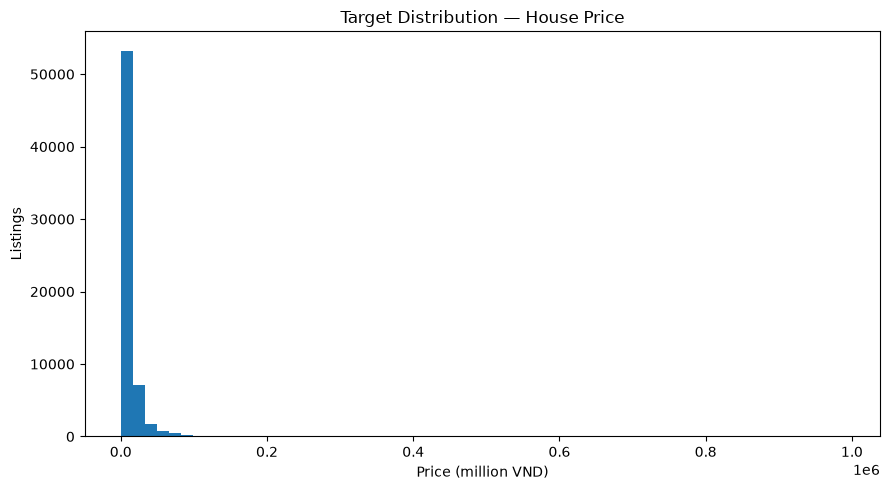

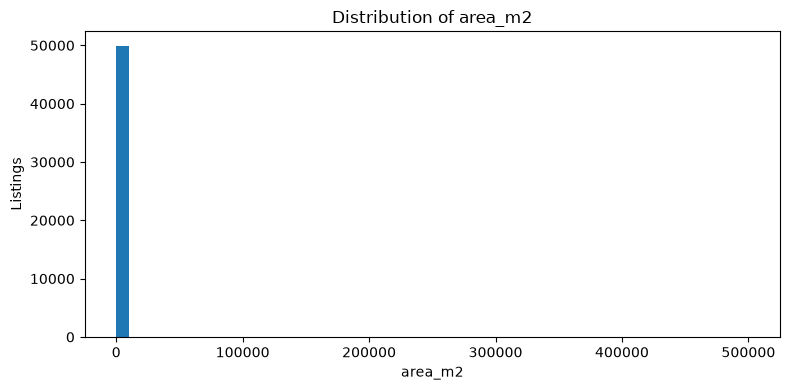

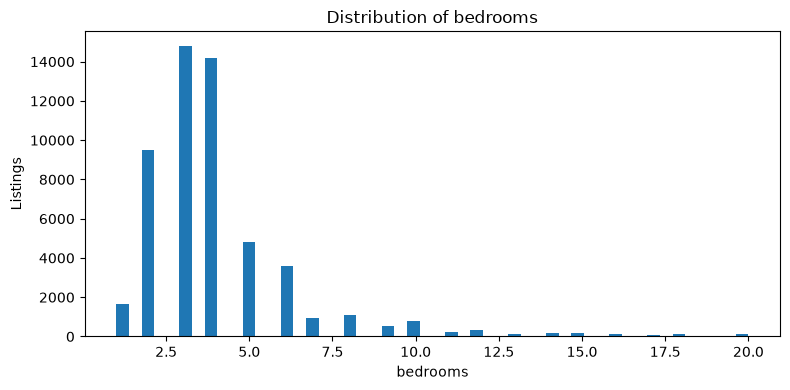

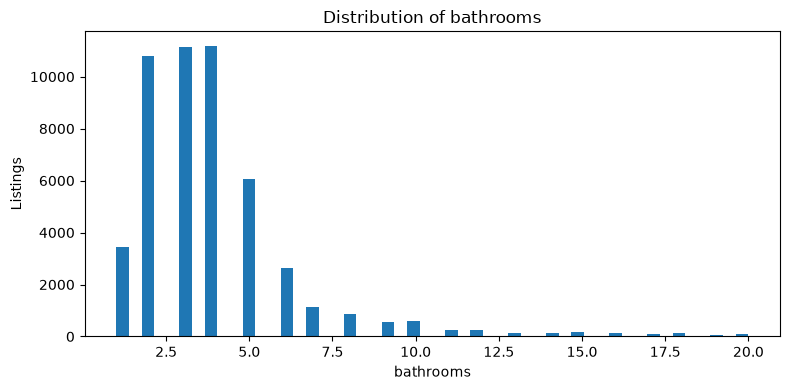

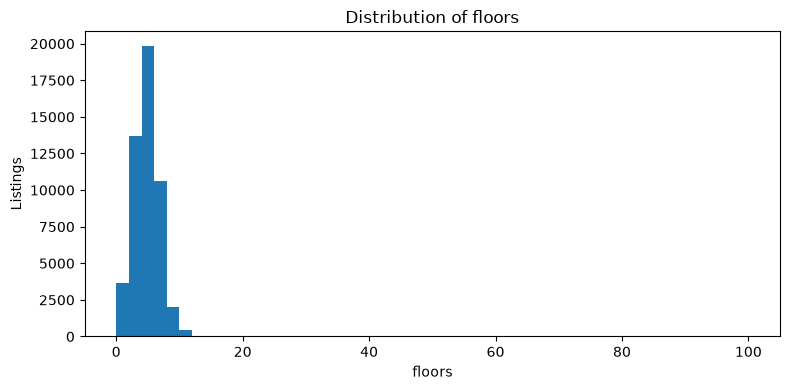

In [8]:
plt.figure(figsize=(9,5))
plt.hist(clean[target_col], bins=60)
plt.xlabel("Price (million VND)")
plt.ylabel("Listings")
plt.title("Target Distribution — House Price")
plt.tight_layout()
plt.show()

for c in ["area_m2","bedrooms","bathrooms","floors"]:
    plt.figure(figsize=(8,4))
    plt.hist(clean[c].dropna(), bins=50)
    plt.xlabel(c)
    plt.ylabel("Listings")
    plt.title(f"Distribution of {c}")
    plt.tight_layout()
    plt.show()

**Observation:** The target and feature histograms show the scale, concentration and tails of the housing variables.

**Interpretation:** Price/area may be strongly skewed and room variables are more discrete.

**ML implication:** linear/distance models benefit from scaling, while tree models do not require scaling. Multiple model families are therefore compared.

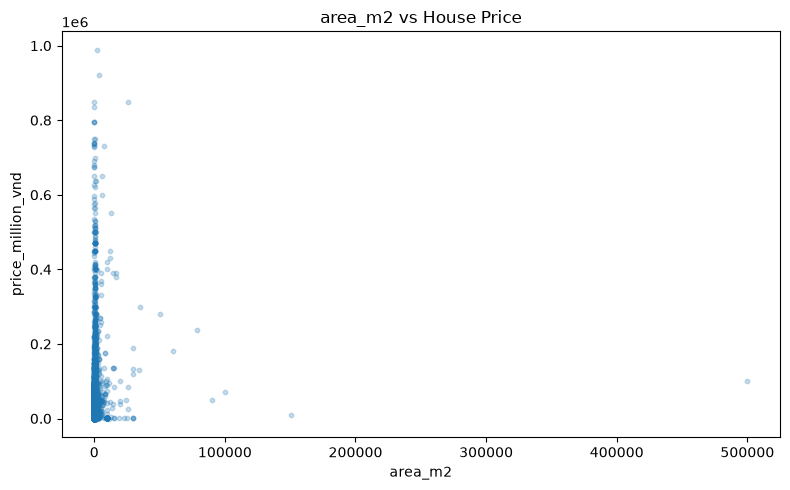

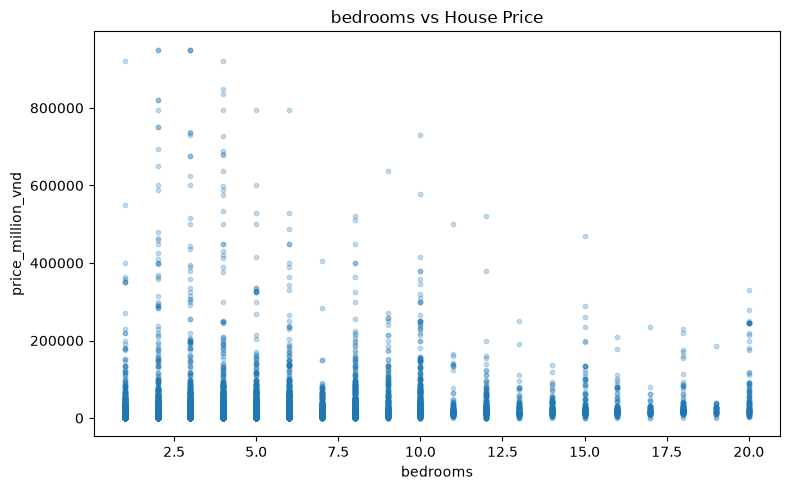

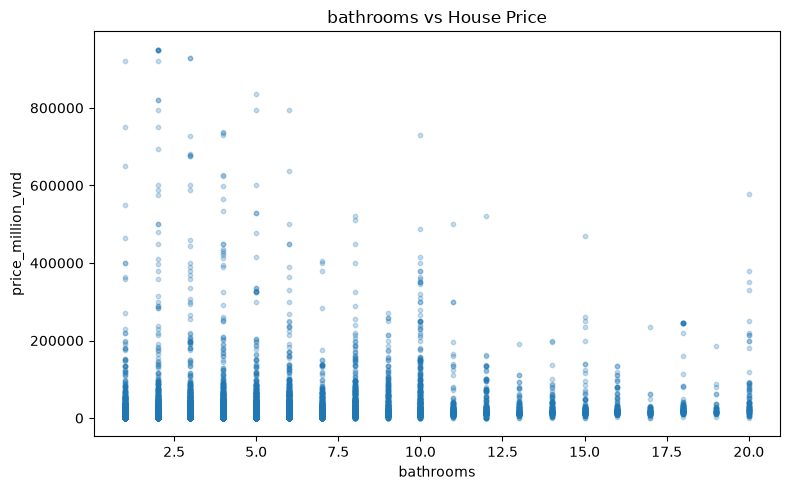

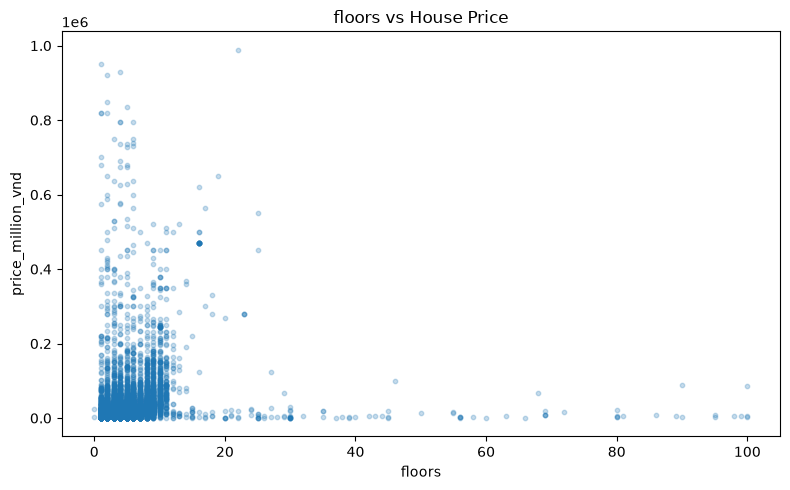

In [9]:
for c in ["area_m2","bedrooms","bathrooms","floors"]:
    tmp = clean[[c,target_col]].dropna()
    plt.figure(figsize=(8,5))
    plt.scatter(tmp[c], tmp[target_col], alpha=.25, s=10)
    plt.xlabel(c)
    plt.ylabel("price_million_vnd")
    plt.title(f"{c} vs House Price")
    plt.tight_layout()
    plt.show()

**Observation:** These scatter plots show the relationship between important house characteristics and price.

**Interpretation:** A systematic trend indicates predictive information, while dispersion indicates that other variables such as location also matter.

**ML implication:** regression is appropriate; nonlinear models can capture interactions beyond simple linear relationships.

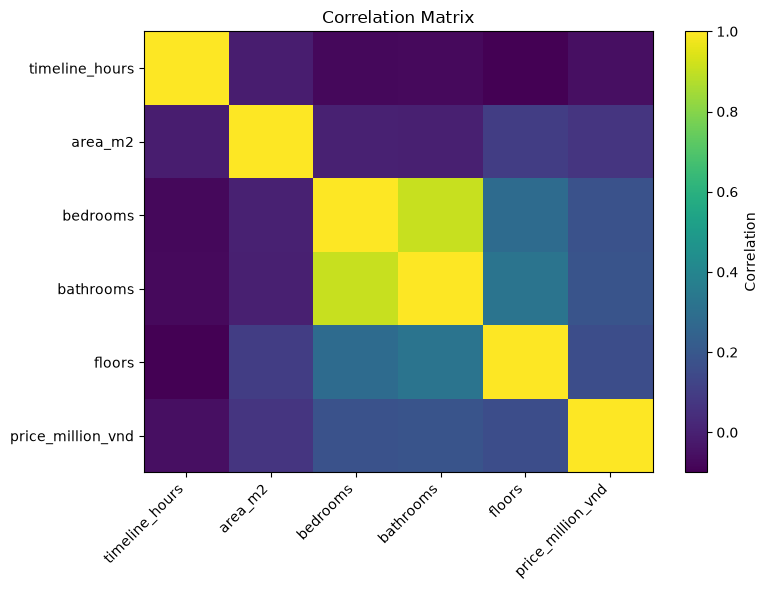

,correlation_with_price
price_million_vnd,1.000000
bathrooms,0.186459
bedrooms,0.177797
floors,0.160374
area_m2,0.070485
timeline_hours,-0.053611


In [10]:
corr_cols = ["timeline_hours","area_m2","bedrooms","bathrooms","floors",target_col]
corr = clean[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(8,6))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

display(corr[target_col].sort_values(ascending=False).to_frame("correlation_with_price"))

**Observation:** The correlation matrix summarizes pairwise linear association among numeric variables.

**Interpretation:** Correlation does not represent categorical location effects or nonlinear interactions.

**ML implication:** correlation is used for EDA, not as the sole feature-selection method.

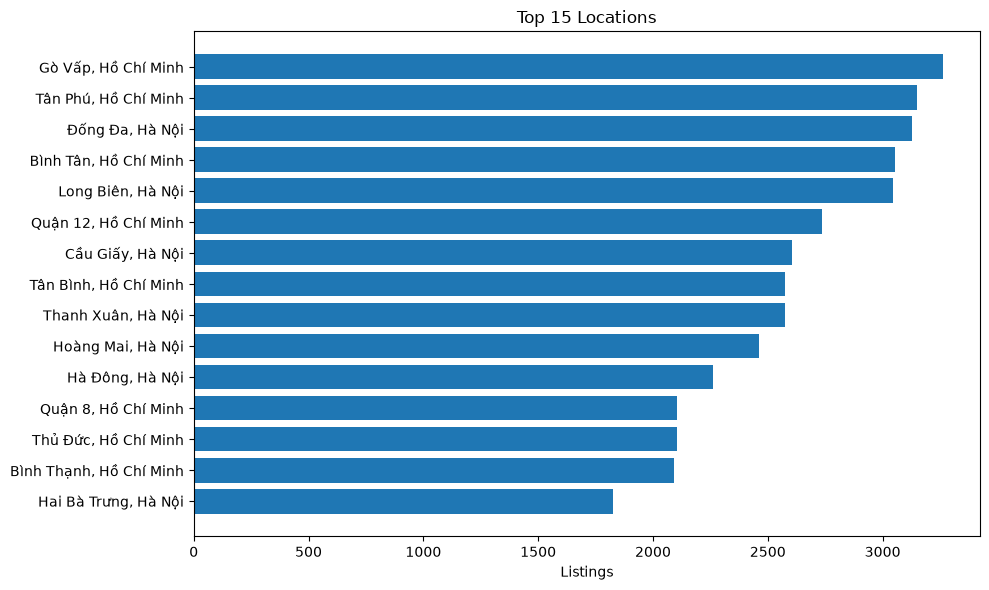

,count,median,mean
location,,,
"Gò Vấp, Hồ Chí Minh",3261,6050.0,9571.490071
"Tân Phú, Hồ Chí Minh",3150,6200.0,8587.321676
"Đống Đa, Hà Nội",3127,10500.0,17967.721266
"Bình Tân, Hồ Chí Minh",3052,5400.0,8362.592659
"Long Biên, Hà Nội",3047,9800.0,15197.756032
"Quận 12, Hồ Chí Minh",2737,5700.0,13588.672558
"Cầu Giấy, Hà Nội",2605,13000.0,21134.449758
"Tân Bình, Hồ Chí Minh",2575,7600.0,12009.213748
"Thanh Xuân, Hà Nội",2573,9300.0,15891.020466


In [11]:
top_locations = clean["location"].value_counts().head(15)
plt.figure(figsize=(10,6))
plt.barh(top_locations.index[::-1], top_locations.values[::-1])
plt.xlabel("Listings")
plt.title("Top 15 Locations")
plt.tight_layout()
plt.show()

display(clean.groupby("location")[target_col].agg(["count","median","mean"]).sort_values("count", ascending=False).head(15))

**Observation:** The dataset has many location categories and several districts have high listing frequency.

**Interpretation:** Location can encode substantial differences in housing prices.

**ML implication:** `location` is retained and one-hot encoded. Unknown categories during inference are handled safely with `handle_unknown='ignore'`.

## 8. Data Representation — Vector and Matrix

In [12]:
X = clean.drop(columns=[target_col])
y = clean[target_col].astype(float)

print("Original dataframe shape:", df.shape)
print("Clean dataframe shape:", clean.shape)
print("Raw X shape:", X.shape)
print("y shape:", y.shape)

print("One raw observation x_i:")
display(X.iloc[0].to_frame("value"))

print("Vector form: x_i = [x_i1, x_i2, ..., x_id]^T")
print("Matrix form: X in R^(N x d), after categorical encoding.")

Original dataframe shape: (66912, 11)
Clean dataframe shape: (64447, 8)
Raw X shape: (64447, 7)
y shape: (64447,)
One raw observation x_i:


,value
location,"Long Biên, Hà Nội"
timeline_hours,2.0
area_m2,50.0
bedrooms,4.0
bathrooms,4.0
floors,6.0
frontage,False


Vector form: x_i = [x_i1, x_i2, ..., x_id]^T
Matrix form: X in R^(N x d), after categorical encoding.


### Required representation

\[
x_i = [x_{i1}, x_{i2}, \ldots, x_{id}]^T
\]

\[
X =
\begin{bmatrix}
x_1^T\\
x_2^T\\
\vdots\\
x_N^T
\end{bmatrix}
\in R^{N\times d}
\]

where **N** is the number of cleaned observations and **d** is the final encoded feature dimension.

### 3.5 Categorical representation

In [13]:
print("Unique locations:", X["location"].nunique(dropna=False))
print("Example values:")
display(pd.DataFrame({"location": X["location"].dropna().drop_duplicates().head(5).tolist()}))

print("Example one-hot idea:")
print("Urban -> [1, 0, 0]")
print("Suburban -> [0, 1, 0]")
print("Rural -> [0, 0, 1]")

Unique locations: 272
Example values:


,location
0,"Long Biên, Hà Nội"
1,"Bình Chánh, Hồ Chí Minh"
2,"Gò Vấp, Hồ Chí Minh"
3,"Cầu Giấy, Hà Nội"
4,"Hà Đông, Hà Nội"


Example one-hot idea:
Urban -> [1, 0, 0]
Suburban -> [0, 1, 0]
Rural -> [0, 0, 1]


## 9. Train / Validation / Test Split — 70% / 15% / 15%

In [14]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=.15, random_state=RANDOM_SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=.15/.85, random_state=RANDOM_SEED
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)
print("Total:", len(X_train)+len(X_val)+len(X_test))

Train: (45112, 7) (45112,)
Validation: (9667, 7) (9667,)
Test: (9668, 7) (9668,)
Total: 64447


### Leakage prevention

The test set is never used to fit preprocessing or select a model. Imputation, scaling and one-hot encoding are fitted inside scikit-learn pipelines using training data. After selecting the model on validation data, the selected pipeline is refitted on train + validation and evaluated once on the untouched test set.

## 10. Preprocessing Pipeline

In [15]:
numeric_features = ["timeline_hours","area_m2","bedrooms","bathrooms","floors"]
categorical_features = ["location"]

preprocessor_scaled = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features)
])

preprocessor_unscaled = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ]), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features)
])

print("Numeric:", numeric_features)
print("Categorical:", categorical_features)

Numeric: ['timeline_hours', 'area_m2', 'bedrooms', 'bathrooms', 'floors']
Categorical: ['location']


## 11. Vector / Matrix / Tensor-style Code

In [16]:
demo = preprocessor_scaled.fit(X_train)
X_demo = demo.transform(X_train)

print("Final encoded matrix shape:", X_demo.shape)
print("Matrix type:", type(X_demo))
print("dtype:", X_demo.dtype)

small = X_demo[:3].toarray() if hasattr(X_demo, "toarray") else np.asarray(X_demo[:3])
print("Small numerical matrix:")
print(small)
print("Shape:", small.shape)

x_i = small[0]
print("One numerical feature vector:")
print(x_i)
print("Shape:", x_i.shape)

B = min(4, len(small))
batch = small[:B]
print("Batch tensor-style representation E shape:", batch.shape, "=(B,d)")
print("B =", B, "; d =", batch.shape[1])

Final encoded matrix shape: (45112, 254)
Matrix type: <class 'scipy.sparse._csr.csr_matrix'>
dtype: float64
Small numerical matrix:
[[-0.61436193 -0.03275653 -0.46483644 -0.31529719  0.27109816  0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.     

### Representation summary

**Raw CSV → DataFrame → Clean Data → Imputation → One-hot encoding → Scaling where needed → Model input**

The final tabular representation is \(X\in R^{N\times d}\). A batch is represented as **B × d**. `location` is converted from categorical strings to binary indicator columns.

## 12. Model Development — Five Required Regression Models

In [17]:
models = {
    "Linear Regression": (preprocessor_scaled, LinearRegression()),
    "Ridge Regression": (preprocessor_scaled, Ridge(alpha=10.0)),
    "Decision Tree Regressor": (
        preprocessor_unscaled,
        DecisionTreeRegressor(max_depth=20, min_samples_leaf=5, random_state=RANDOM_SEED)
    ),
    "Random Forest Regressor": (
        preprocessor_unscaled,
        RandomForestRegressor(
            n_estimators=150, max_depth=25, min_samples_leaf=2,
            n_jobs=-1, random_state=RANDOM_SEED
        )
    ),
    "Gradient Boosting Regressor": (
        preprocessor_unscaled,
        GradientBoostingRegressor(
            n_estimators=150, learning_rate=.05, max_depth=3,
            min_samples_leaf=5, random_state=RANDOM_SEED
        )
    )
}

pipelines = {
    name: Pipeline([("preprocessor", prep), ("model", estimator)])
    for name, (prep, estimator) in models.items()
}
print(list(pipelines))

['Linear Regression', 'Ridge Regression', 'Decision Tree Regressor', 'Random Forest Regressor', 'Gradient Boosting Regressor']


In [18]:
def metrics(y_true, pred):
    mse = mean_squared_error(y_true, pred)
    return {
        "MAE": mean_absolute_error(y_true, pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, pred)
    }

rows = []
for name, pipe in pipelines.items():
    print("Training:", name)
    start = time.perf_counter()
    pipe.fit(X_train, y_train)
    seconds = time.perf_counter() - start
    pred = pipe.predict(X_val)
    row = metrics(y_val, pred)
    row["Training Time (s)"] = seconds
    row["Model"] = name
    rows.append(row)

validation_results = pd.DataFrame(rows).set_index("Model").sort_values("RMSE")
display(validation_results)

Training: Linear Regression
Training: Ridge Regression
Training: Decision Tree Regressor
Training: Random Forest Regressor
Training: Gradient Boosting Regressor


,MAE,MSE,RMSE,R2,Training Time (s)
Model,,,,,
Random Forest Regressor,7331.530847,1.042957e+09,32294.848101,0.302071,19.858034
Decision Tree Regressor,7971.505249,1.129217e+09,33603.825296,0.244347,0.815494
Gradient Boosting Regressor,8224.980583,1.148347e+09,33887.264162,0.231546,7.934456
Linear Regression,10384.543429,1.396286e+09,37366.913849,0.065629,0.227206
Ridge Regression,10363.557656,1.396369e+09,37368.026673,0.065573,0.143312


## 13. Model Evaluation

For house-price regression:

- **MAE:** average absolute error, in million VND.
- **MSE:** average squared error; penalizes large errors strongly.
- **RMSE:** square root of MSE, in million VND.
- **R²:** proportion of variance explained by the model.

Lower MAE/MSE/RMSE and higher R² are preferred.

In [19]:
comparison_table = validation_results[["MAE","MSE","RMSE","R2","Training Time (s)"]]
display(comparison_table)

best_model_name = comparison_table["RMSE"].idxmin()
print("Selected by lowest validation RMSE:", best_model_name)

,MAE,MSE,RMSE,R2,Training Time (s)
Model,,,,,
Random Forest Regressor,7331.530847,1.042957e+09,32294.848101,0.302071,19.858034
Decision Tree Regressor,7971.505249,1.129217e+09,33603.825296,0.244347,0.815494
Gradient Boosting Regressor,8224.980583,1.148347e+09,33887.264162,0.231546,7.934456
Linear Regression,10384.543429,1.396286e+09,37366.913849,0.065629,0.227206
Ridge Regression,10363.557656,1.396369e+09,37368.026673,0.065573,0.143312


Selected by lowest validation RMSE: Random Forest Regressor


## 14. Final Model Selection and Test Evaluation

In [20]:
X_train_final = pd.concat([X_train, X_val])
y_train_final = pd.concat([y_train, y_val])

selected_prep, selected_estimator = models[best_model_name]
final_pipeline = Pipeline([
    ("preprocessor", selected_prep),
    ("model", selected_estimator)
])

start = time.perf_counter()
final_pipeline.fit(X_train_final, y_train_final)
final_time = time.perf_counter() - start

test_pred = final_pipeline.predict(X_test)
test_metrics = metrics(y_test, test_pred)
test_metrics["Training Time (s)"] = final_time

display(pd.DataFrame([test_metrics], index=[best_model_name]))

,MAE,MSE,RMSE,R2,Training Time (s)
Random Forest Regressor,7595.369815,1.134177e+09,33677.54179,0.264042,24.098922


### Model-selection justification

The winner is chosen using validation RMSE. It is then retrained on train + validation. The test set is used only for the final estimate, so test performance does not influence model selection.

The final deployment choice should consider predictive performance, robustness, interpretability, computational cost and reproducibility.

## 15. Error Analysis

,actual,predicted,error,abs_error,pct_error
1795,920000.0,965.014891,-919034.985109,919034.985109,99.895107
2219,950000.0,48153.616450,-901846.383550,901846.383550,94.931198
804,820000.0,12626.173955,-807373.826045,807373.826045,98.460223
424,795000.0,4662.476422,-790337.523578,790337.523578,99.413525
2587,735000.0,5385.206128,-729614.793872,729614.793872,99.267319
537,735000.0,7510.681226,-727489.318774,727489.318774,98.978139
5977,728000.0,6367.050853,-721632.949147,721632.949147,99.125405
2149,675000.0,10591.352806,-664408.647194,664408.647194,98.430911
1005,628000.0,8828.823186,-619171.176814,619171.176814,98.594136
3269,600000.0,4662.476422,-595337.523578,595337.523578,99.222921


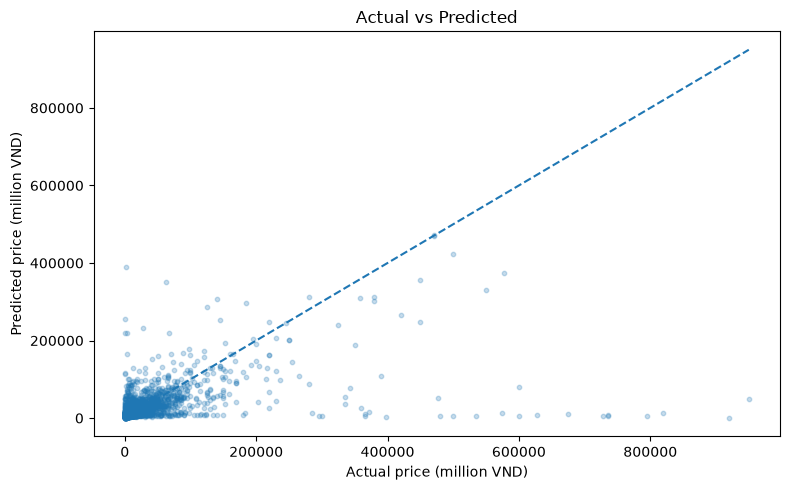

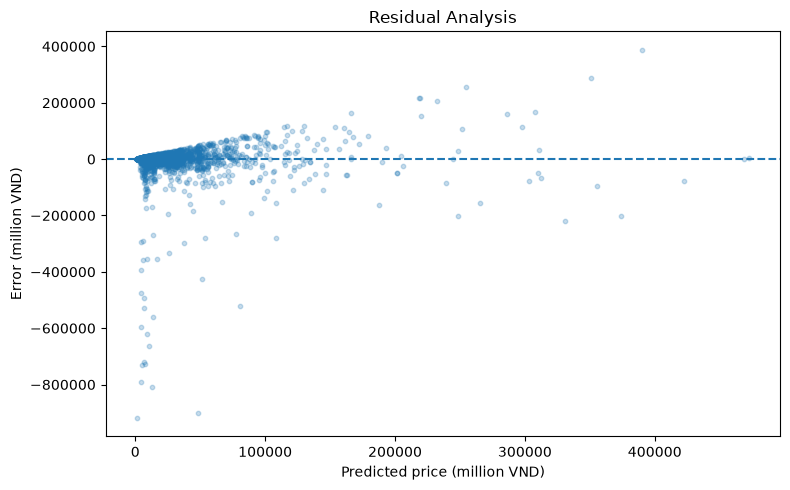

In [21]:
errors = pd.DataFrame({"actual": y_test.values, "predicted": test_pred})
errors["error"] = errors["predicted"] - errors["actual"]
errors["abs_error"] = errors["error"].abs()
errors["pct_error"] = errors["abs_error"] / errors["actual"] * 100

display(errors.sort_values("abs_error", ascending=False).head(10))

plt.figure(figsize=(8,5))
plt.scatter(errors["actual"], errors["predicted"], alpha=.25, s=10)
lims = [min(errors["actual"].min(), errors["predicted"].min()),
        max(errors["actual"].max(), errors["predicted"].max())]
plt.plot(lims, lims, linestyle="--")
plt.xlabel("Actual price (million VND)")
plt.ylabel("Predicted price (million VND)")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(errors["predicted"], errors["error"], alpha=.25, s=10)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted price (million VND)")
plt.ylabel("Error (million VND)")
plt.title("Residual Analysis")
plt.tight_layout()
plt.show()

**Interpretation:** Large residuals show houses that are difficult to predict. Potential causes include unusual properties, location-specific effects, missing attributes, and noise in asking prices. These cases are useful for future feature engineering.

## 16. Model Persistence

In [22]:
pipeline_path = MODEL_DIR / "model_pipeline.joblib"
preprocessor_path = MODEL_DIR / "preprocessor.joblib"
model_path = MODEL_DIR / "model.joblib"
config_path = MODEL_DIR / "model_config.json"

joblib.dump(final_pipeline, pipeline_path)
joblib.dump(final_pipeline.named_steps["preprocessor"], preprocessor_path)
joblib.dump(final_pipeline.named_steps["model"], model_path)

config = {
    "random_seed": RANDOM_SEED,
    "task": "regression",
    "target": target_col,
    "selected_model": best_model_name,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "dropped_columns": drop_cols,
    "split": {"train": .70, "validation": .15, "test": .15},
    "target_unit": "million VND",
    "preprocessing": {
        "numeric_imputation": "median",
        "categorical_imputation": "most_frequent",
        "categorical_encoding": "OneHotEncoder(handle_unknown=ignore)",
        "scaling": "StandardScaler for Linear/Ridge; no scaling for tree models"
    }
}
with open(config_path, "w", encoding="utf-8") as f:
    json.dump(config, f, ensure_ascii=False, indent=2)

for p in [pipeline_path, preprocessor_path, model_path, config_path]:
    print(p)

D:\Dai hoc\Phat trien cac he thong thong minh\Assignment_02\house_price\model\model_pipeline.joblib
D:\Dai hoc\Phat trien cac he thong thong minh\Assignment_02\house_price\model\preprocessor.joblib
D:\Dai hoc\Phat trien cac he thong thong minh\Assignment_02\house_price\model\model.joblib
D:\Dai hoc\Phat trien cac he thong thong minh\Assignment_02\house_price\model\model_config.json


### Persistence requirement

The assignment requires saving preprocessing, feature transformation, the trained model and configuration. `model_pipeline.joblib` contains the complete inference chain. The separate `preprocessor.joblib`, `model.joblib`, and `model_config.json` also satisfy the Appendix A persistence layout.

## 17. Inference Test

In [23]:
loaded_pipeline = joblib.load(pipeline_path)

sample_input = X_test.iloc[[0]].copy()
actual = float(y_test.iloc[0])
predicted = float(loaded_pipeline.predict(sample_input)[0])

display(sample_input)
print(f"Actual: {actual:,.2f} million VND")
print(f"Predicted: {predicted:,.2f} million VND")

,location,timeline_hours,area_m2,bedrooms,bathrooms,floors,frontage
52852,"Hoàn Kiếm, Hà Nội",2160.0,50.0,8.0,5.0,5.0,True


Actual: 52,900.00 million VND
Predicted: 29,870.81 million VND


## 18. Reproducibility

In [24]:
import sklearn
print("Python:", sys.version)
print("OS:", platform.platform())
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("joblib:", joblib.__version__)
print("Random seed:", RANDOM_SEED)
print("Raw observations:", len(df))
print("Clean observations:", len(clean))
print("Final model:", best_model_name)

Python: 3.14.6 | packaged by Anaconda, Inc. | (main, Jul  9 2026, 14:29:05) [MSC v.1942 64 bit (AMD64)]
OS: Windows-11-10.0.26200-SP0
pandas: 3.0.5
numpy: 2.5.1
scikit-learn: 1.9.0
joblib: 1.5.3
Random seed: 42
Raw observations: 66912
Clean observations: 64447
Final model: Random Forest Regressor


## 19. Deployment Handoff

Required deployment architecture:

**User Input → Validation → Same Preprocessing → Saved Model → Prediction**

The API should load `model_pipeline.joblib` and perform inference without retraining. The same preprocessing used during training must be used during deployment. A suitable house-price response is:

```json
{"predicted_price": 285000}
```

The web and mobile applications are separate deployment deliverables; this notebook supplies the persisted ML artifacts they consume.

## 20. Discussion Questions

1. **One observation?** One house listing.
2. **Raw representation?** One CSV row.
3. **Final numerical representation?** Imputed numeric features + one-hot encoded location.
4. **Dimensions?** N = observations; d = encoded model features.
5. **Categorical encoding?** One-hot encoding.
6. **Normalization?** StandardScaler for Linear/Ridge.
7. **Removed information?** ID, URL and title from the baseline model.
8. **Leakage risk?** Fitting preprocessing using validation/test/user data.
9. **Best model?** Lowest validation RMSE.
10. **Evaluation?** MAE, MSE, RMSE and R².
11. **Persistence?** joblib.
12. **Inference?** Load the persisted pipeline and predict without retraining.

## 21. Final Checklist

- [x] Problem definition
- [x] Dataset loading and inspection
- [x] Missing / duplicate / invalid / outlier analysis
- [x] Numerical, categorical, text and target identification
- [x] Cleaning with reasons
- [x] Vector and matrix representation
- [x] Categorical one-hot representation
- [x] B × d batch/tensor-style representation
- [x] Target, feature, relationship and correlation EDA
- [x] 70/15/15 split
- [x] Leakage prevention
- [x] Five regression models
- [x] MAE / MSE / RMSE / R²
- [x] Model comparison
- [x] Error analysis
- [x] Final model selection
- [x] Preprocessor + model + complete pipeline persistence
- [x] Configuration persistence
- [x] Inference test

**Appendix A:** notebook → `house_price/notebook/`; dataset → `house_price/data/`; model artifacts → `house_price/model/`.